# Irrigation Need — Notebook 4: XGBoost
**Kaggle Playground S6E4**

Inputs:
- `Data/processed/train_unscaled.parquet`
- `Data/processed/test_unscaled.parquet`
- `Data/processed/sample_weights.parquet`
- `Data/processed/class_weights.pkl`
- `Data/processed/target_map.pkl`

Outputs:
- `submissions/submission_xgb.csv`
- `models/xgb_best_params.pkl`
- `models/xgb_oof_preds.parquet`
- `models/xgb_test_probs.parquet`

Key decisions carried from notebook 3:
- Feature set: v2 (27 features — raw originals + logit/prob/score, no binary threshold flags)
- Same 3-param grid approach (no Optuna)
- Sample weights for class imbalance (High = 10x)
- LightGBM OOF baseline to beat: 0.9705


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from matplotlib.patches import Patch

pd.set_option('display.float_format', '{:.4f}'.format)
PALETTE = {'Low': '#02C39A', 'Medium': '#F4A261', 'High': '#E63946'}
SEED    = 42
N_FOLDS = 5

LGBM_OOF_BA = 0.9705  # baseline to beat

os.makedirs('../models', exist_ok=True)
os.makedirs('../submissions', exist_ok=True)
print(f'XGBoost version: {xgb.__version__}')
print('Setup complete.')

XGBoost version: 2.1.4
Setup complete.


## 1. Load Data

In [2]:
train = pd.read_parquet('../Data/processed/train_unscaled.parquet')
test  = pd.read_parquet('../Data/processed/test_unscaled.parquet')

with open('../Data/processed/target_map.pkl', 'rb') as f:
    tm = pickle.load(f)
target_inv = tm['inv']  # {0: 'Low', 1: 'Medium', 2: 'High'}

sample_weights = pd.read_parquet('../Data/processed/sample_weights.parquet')['sample_weight'].values

y      = train['Irrigation_Need'].values
X      = train.drop(columns=['Irrigation_Need'])
X_test = test.copy()

print(f'Train : {X.shape}')
print(f'Test  : {X_test.shape}')
print(f'Target: {pd.Series(y).value_counts().to_dict()}')

Train : (630000, 38)
Test  : (270000, 38)
Target: {0: 369917, 1: 239074, 2: 21009}


## 2. Feature Set — v2 (same as notebook 3)

In [3]:
# Drop binary threshold flags — LightGBM showed these add no value
# Raw continuous values + logit/prob/score features only
drop_binary = [
    'soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10',
    'CGS_Flowering', 'CGS_Harvest', 'CGS_Sowing', 'CGS_Vegetative',
    'mulch_no', 'mulch_yes'
]

FEATURE_COLS = [c for c in X.columns if c not in drop_binary]

X_arr      = X[FEATURE_COLS].values
X_test_arr = X_test[FEATURE_COLS].values

print(f'v2 feature set: {len(FEATURE_COLS)} features')
print(FEATURE_COLS)

v2 feature set: 28 features
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'logit_low', 'logit_medium', 'logit_high', 'prob_low', 'prob_medium', 'prob_high', 'rule_score', 'logit_margin', '_drop_in_v2']


## 3. Manual Grid Search

In [7]:
# XGBoost differences vs LightGBM:
# - use_label_encoder=False + eval_metric='mlogloss' required
# - tree_method='hist' for speed on large datasets
# - scale_pos_weight not used for multiclass — sample_weight handles imbalance
# - max_leaves replaces num_leaves (in hist mode)
# - gamma = min_split_gain equivalent

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

COMMON = {
    'objective':        'multi:softprob',
    'num_class':        3,
    'eval_metric':      'mlogloss',
    'tree_method':      'hist',
    'random_state':     SEED,
    'verbosity':        0,
}

param_grid = {
    'conservative': {
        **COMMON,
        'n_estimators':      500,
        'learning_rate':     0.05,
        'max_depth':         6,
        'max_leaves':        63,
        'min_child_weight':  50,
        'subsample':         0.8,
        'colsample_bytree':  0.8,
        'reg_alpha':         0.1,
        'reg_lambda':        1.0,
        'gamma':             0.1,
    },
    'deeper': {
        **COMMON,
        'n_estimators':      800,
        'learning_rate':     0.03,
        'max_depth':         8,
        'max_leaves':        127,
        'min_child_weight':  30,
        'subsample':         0.7,
        'colsample_bytree':  0.7,
        'reg_alpha':         0.05,
        'reg_lambda':        0.5,
        'gamma':             0.05,
    },
    'fast': {
        **COMMON,
        'n_estimators':      500,
        'learning_rate':     0.1,
        'max_depth':         5,
        'max_leaves':        31,
        'min_child_weight':  100,
        'subsample':         0.9,
        'colsample_bytree':  0.9,
        'reg_alpha':         0.01,
        'reg_lambda':        0.1,
        'gamma':             0.0,
    },
}

grid_results = {}

print('=== Manual Grid Search (3 param sets × 5 folds = 15 fits) ===')
for name, params in param_grid.items():
    fold_scores = []
    for tr_idx, val_idx in skf.split(X_arr, y):
        X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            sample_weight=sample_weights[tr_idx],
            eval_set=[(X_val, y_val)],
            verbose=False,
        )
        preds = model.predict(X_val)
        fold_scores.append(balanced_accuracy_score(y_val, preds))

    mean_ba = np.mean(fold_scores)
    grid_results[name] = {'mean_ba': mean_ba, 'fold_scores': fold_scores, 'params': params}
    print(f'  {name:15s} → BA: {mean_ba:.4f}  folds: {[round(s,4) for s in fold_scores]}')

best_name   = max(grid_results, key=lambda k: grid_results[k]['mean_ba'])
best_params = grid_results[best_name]['params']
best_ba     = grid_results[best_name]['mean_ba']

print(f'\nBest param set  : {best_name}')
print(f'Best CV BA      : {best_ba:.4f}')
print(f'LightGBM OOF    : {LGBM_OOF_BA:.4f}')
print(f'vs LightGBM     : {best_ba - LGBM_OOF_BA:+.4f}')

=== Manual Grid Search (3 param sets × 5 folds = 15 fits) ===
  conservative    → BA: 0.9716  folds: [0.97, 0.9727, 0.9726, 0.9711, 0.9715]
  deeper          → BA: 0.9698  folds: [0.9688, 0.9709, 0.9708, 0.9692, 0.9692]
  fast            → BA: 0.9719  folds: [0.9704, 0.9727, 0.9733, 0.9716, 0.9717]

Best param set  : fast
Best CV BA      : 0.9719
LightGBM OOF    : 0.9705
vs LightGBM     : +0.0014


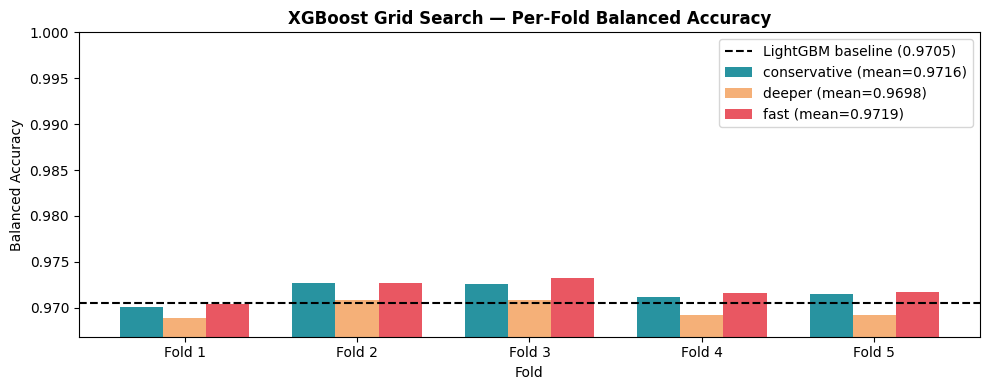

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
x      = np.arange(N_FOLDS)
width  = 0.25
colors_grid = ['#028090', '#F4A261', '#E63946']

for i, (name, res) in enumerate(grid_results.items()):
    ax.bar(x + i*width, res['fold_scores'], width,
           label=f"{name} (mean={res['mean_ba']:.4f})",
           color=colors_grid[i], alpha=0.85)

ax.axhline(LGBM_OOF_BA, color='black', linestyle='--', linewidth=1.5,
           label=f'LightGBM baseline ({LGBM_OOF_BA:.4f})')
ax.set_xlabel('Fold')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('XGBoost Grid Search — Per-Fold Balanced Accuracy', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.legend()
ax.set_ylim(min(s for r in grid_results.values() for s in r['fold_scores']) - 0.002, 1.0)
plt.tight_layout()
plt.show()

## 4. Final Model — OOF + Test Predictions

In [11]:
oof_preds   = np.zeros(len(X), dtype=int)
oof_probs   = np.zeros((len(X), 3))
test_probs  = np.zeros((len(X_test), 3))
fold_scores = []

print(f'=== Final Model ({best_name}) — {N_FOLDS}-Fold CV ===')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_arr, y)):
    X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model = xgb.XGBClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        sample_weight=sample_weights[tr_idx],
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_probs          = model.predict_proba(X_val)
    val_preds          = np.argmax(val_probs, axis=1)
    oof_preds[val_idx] = val_preds
    oof_probs[val_idx] = val_probs
    test_probs        += model.predict_proba(X_test_arr) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_val, val_preds)
    fold_scores.append(fold_ba)
    print(f'  Fold {fold+1}: BA = {fold_ba:.4f}')

oof_ba = balanced_accuracy_score(y, oof_preds)
print(f'\nOOF Balanced Accuracy : {oof_ba:.4f}')
print(f'Mean fold BA          : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')
print(f'LightGBM OOF          : {LGBM_OOF_BA:.4f}')
print(f'vs LightGBM           : {oof_ba - LGBM_OOF_BA:+.4f}')

=== Final Model (fast) — 5-Fold CV ===
  Fold 1: BA = 0.9704
  Fold 2: BA = 0.9727
  Fold 3: BA = 0.9733
  Fold 4: BA = 0.9716
  Fold 5: BA = 0.9717

OOF Balanced Accuracy : 0.9719
Mean fold BA          : 0.9719 ± 0.0010
LightGBM OOF          : 0.9705
vs LightGBM           : +0.0014


## 5. OOF Diagnostics

=== OOF Classification Report ===
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074
        High       0.90      0.95      0.92     21009

    accuracy                           0.98    630000
   macro avg       0.96      0.97      0.96    630000
weighted avg       0.98      0.98      0.98    630000



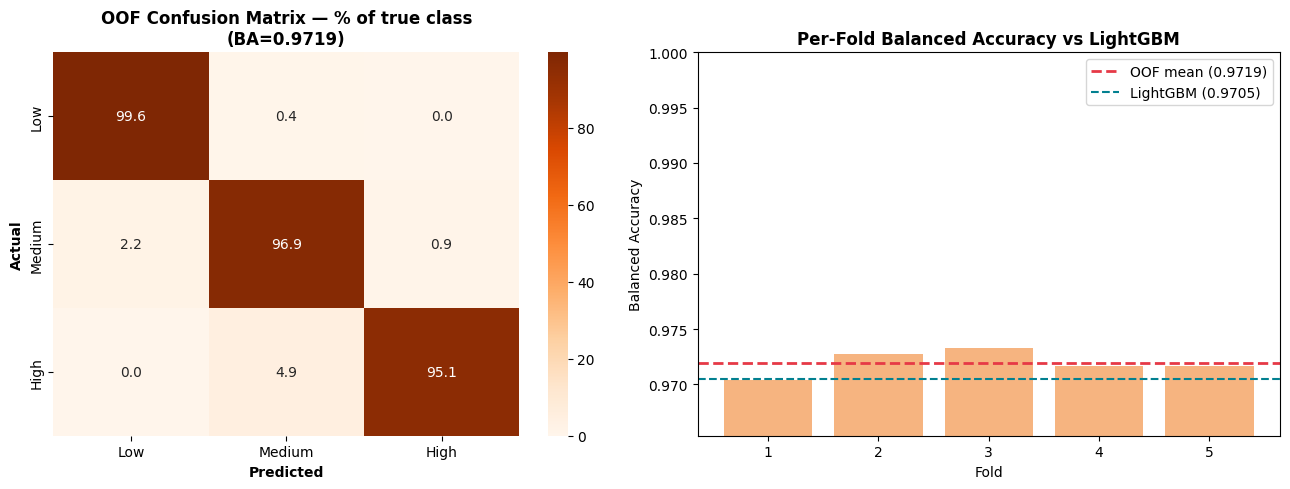

In [12]:
print('=== OOF Classification Report ===')
print(classification_report(y, oof_preds, target_names=['Low', 'Medium', 'High']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm     = confusion_matrix(y, oof_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'], ax=axes[0])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title(f'OOF Confusion Matrix — % of true class\n(BA={oof_ba:.4f})', fontweight='bold')

axes[1].bar(range(1, N_FOLDS+1), fold_scores, color='#F4A261', alpha=0.8)
axes[1].axhline(oof_ba, color='#E63946', linestyle='--', linewidth=2,
                label=f'OOF mean ({oof_ba:.4f})')
axes[1].axhline(LGBM_OOF_BA, color='#028090', linestyle='--', linewidth=1.5,
                label=f'LightGBM ({LGBM_OOF_BA:.4f})')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('Per-Fold Balanced Accuracy vs LightGBM', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(min(fold_scores) - 0.005, 1.0)
plt.tight_layout()
plt.show()

## 6. Feature Importance

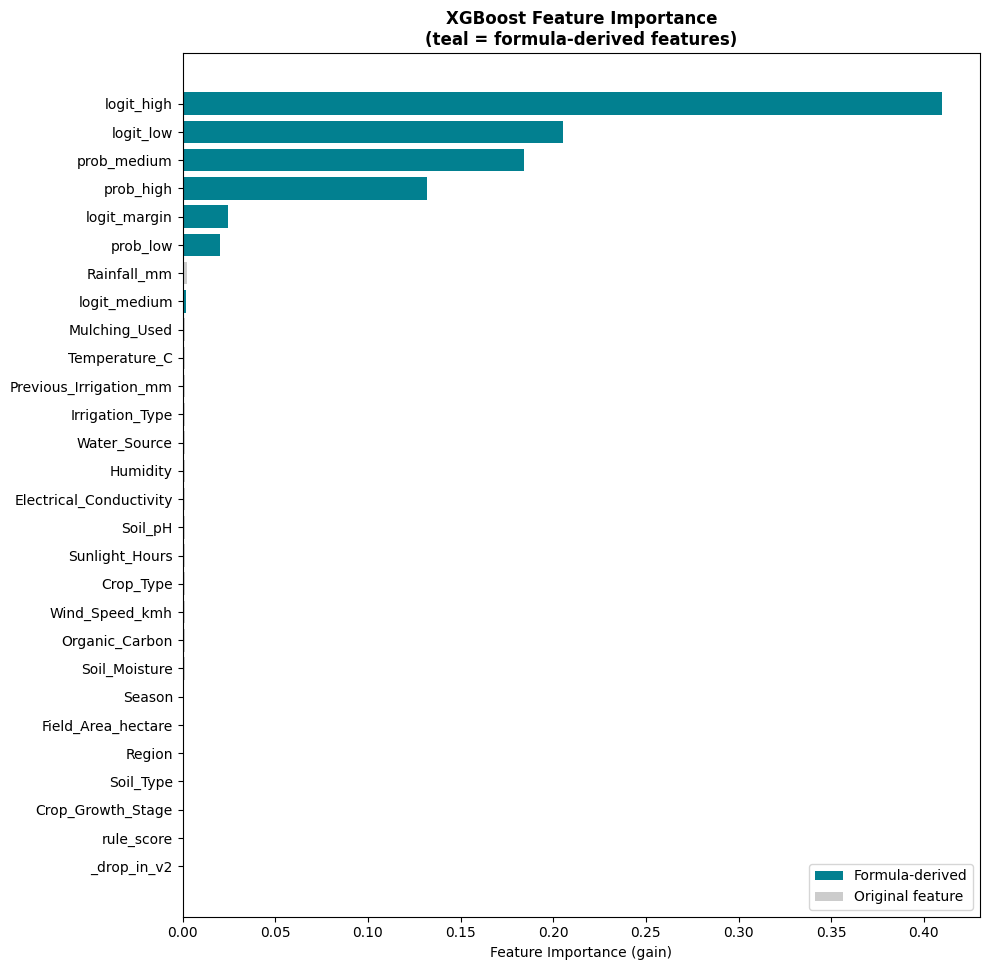

Top 15 features:
logit_high                0.4098
logit_low                 0.2054
prob_medium               0.1844
prob_high                 0.1316
logit_margin              0.0244
prob_low                  0.0201
Rainfall_mm               0.0025
logit_medium              0.0017
Mulching_Used             0.0014
Temperature_C             0.0013
Previous_Irrigation_mm    0.0013
Irrigation_Type           0.0013
Water_Source              0.0012
Humidity                  0.0012
Electrical_Conductivity   0.0012


In [13]:
formula_derived = [
    'logit_low', 'logit_medium', 'logit_high',
    'prob_low', 'prob_medium', 'prob_high',
    'rule_score', 'logit_margin'
]

fi = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

colors_fi = ['#028090' if f in formula_derived else '#cccccc' for f in fi.index]

fig, ax = plt.subplots(figsize=(10, max(6, len(fi)*0.35)))
ax.barh(fi.index, fi.values, color=colors_fi)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance\n(teal = formula-derived features)', fontweight='bold')
legend_elements = [Patch(facecolor='#028090', label='Formula-derived'),
                   Patch(facecolor='#cccccc', label='Original feature')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 15 features:')
print(fi.sort_values(ascending=False).head(15).to_string())

## 7. Model Comparison — LightGBM vs XGBoost

In [14]:
# Load LightGBM OOF probs for correlation analysis
lgbm_oof = pd.read_parquet('../models/lgbm_oof_preds.parquet')

# Agreement between models
lgbm_preds = lgbm_oof['oof_pred'].values
agreement  = (lgbm_preds == oof_preds).mean()
print(f'LightGBM vs XGBoost prediction agreement: {agreement:.4f} ({agreement*100:.1f}%)')

# Where they disagree — are those the hard cases?
disagree_mask = lgbm_preds != oof_preds
print(f'\nDisagreement on {disagree_mask.sum():,} rows ({disagree_mask.mean()*100:.1f}%)')
print('True class distribution on disagreements:')
print(pd.Series(y[disagree_mask]).map(target_inv).value_counts())

# Accuracy on disagreements
lgbm_right = (lgbm_preds[disagree_mask] == y[disagree_mask]).mean()
xgb_right  = (oof_preds[disagree_mask]  == y[disagree_mask]).mean()
print(f'\nOn disagreements:')
print(f'  LightGBM correct: {lgbm_right:.3f}')
print(f'  XGBoost correct : {xgb_right:.3f}')
print(f'  → Ensemble potential: cases where one is right and one is wrong')

LightGBM vs XGBoost prediction agreement: 0.9975 (99.8%)

Disagreement on 1,547 rows (0.2%)
True class distribution on disagreements:
Medium    1199
High       197
Low        151
Name: count, dtype: int64

On disagreements:
  LightGBM correct: 0.509
  XGBoost correct : 0.491
  → Ensemble potential: cases where one is right and one is wrong


## 8. Prediction Distribution Check

=== Prediction Distribution Sanity Check ===
  Train true  : Low 58.7%  Medium 37.9%  High 3.3%
  OOF preds   : Low 59.3%  Medium 37.2%  High 3.5%
  Test preds  : Low 59.2%  Medium 37.2%  High 3.5%


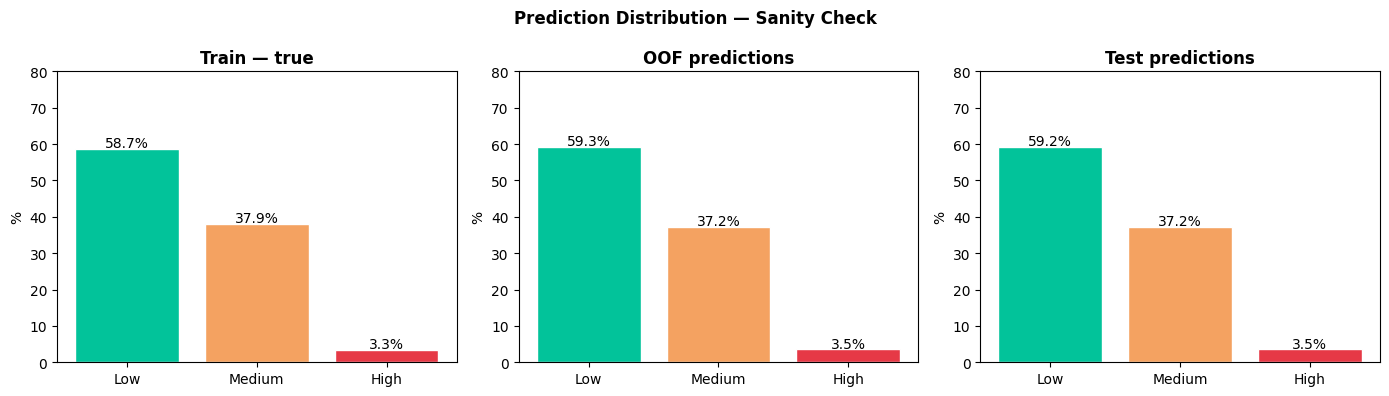

In [15]:
test_preds  = np.argmax(test_probs, axis=1)
test_labels = pd.Series(test_preds).map(target_inv)
oof_labels  = pd.Series(oof_preds).map(target_inv)
true_labels = pd.Series(y).map(target_inv)

order = ['Low', 'Medium', 'High']
print('=== Prediction Distribution Sanity Check ===')
for name, series in [('Train true', true_labels),
                     ('OOF preds',  oof_labels),
                     ('Test preds', test_labels)]:
    vc = series.value_counts(normalize=True).reindex(order).mul(100).round(1)
    print(f'  {name:12s}: Low {vc["Low"]}%  Medium {vc["Medium"]}%  High {vc["High"]}%')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_bar = [PALETTE[c] for c in order]
for ax, (title, series) in zip(axes, [
    ('Train — true',    true_labels),
    ('OOF predictions', oof_labels),
    ('Test predictions', test_labels),
]):
    vc = series.value_counts(normalize=True).reindex(order) * 100
    ax.bar(order, vc.values, color=colors_bar, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_ylim(0, 80)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Prediction Distribution — Sanity Check', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Save Outputs

In [16]:
# Submission
submission = pd.DataFrame({
    'id': X_test.index,
    'Irrigation_Need': test_labels.values
})
submission.to_csv('../submissions/submission_xgb.csv', index=False)
print('Saved: submissions/submission_xgb.csv')
print(submission['Irrigation_Need'].value_counts())

# OOF predictions for ensemble
oof_df = pd.DataFrame({
    'y_true':          y,
    'oof_pred':        oof_preds,
    'oof_prob_low':    oof_probs[:, 0],
    'oof_prob_medium': oof_probs[:, 1],
    'oof_prob_high':   oof_probs[:, 2],
}, index=X.index)
oof_df.to_parquet('../models/xgb_oof_preds.parquet')
print('Saved: models/xgb_oof_preds.parquet')

# Test probabilities for ensemble
test_probs_df = pd.DataFrame(
    test_probs,
    columns=['xgb_prob_low', 'xgb_prob_medium', 'xgb_prob_high'],
    index=X_test.index
)
test_probs_df.to_parquet('../models/xgb_test_probs.parquet')
print('Saved: models/xgb_test_probs.parquet')

# Best params
with open('../models/xgb_best_params.pkl', 'wb') as f:
    pickle.dump({'name': best_name, 'params': best_params}, f)
print('Saved: models/xgb_best_params.pkl')

Saved: submissions/submission_xgb.csv
Irrigation_Need
Low       159886
Medium    100568
High        9546
Name: count, dtype: int64
Saved: models/xgb_oof_preds.parquet
Saved: models/xgb_test_probs.parquet
Saved: models/xgb_best_params.pkl


## 10. Summary

In [17]:
print('=' * 65)
print('XGBOOST SUMMARY')
print('=' * 65)
print(f"""
FEATURE SET
  v2 — {len(FEATURE_COLS)} features (raw originals + logit/prob/score)
  Binary threshold flags dropped (confirmed redundant in NB3)

GRID SEARCH
""")
for name, res in grid_results.items():
    marker = ' ← best' if name == best_name else ''
    print(f'  {name:15s}: {res["mean_ba"]:.4f}{marker}')

print(f"""
FINAL MODEL ({best_name})
  OOF Balanced Accuracy : {oof_ba:.4f}
  Fold scores           : {[round(s,4) for s in fold_scores]}
  Std across folds      : {np.std(fold_scores):.4f}

MODEL COMPARISON
  LightGBM OOF          : {LGBM_OOF_BA:.4f}
  XGBoost  OOF          : {oof_ba:.4f}
  Delta                 : {oof_ba - LGBM_OOF_BA:+.4f}
  Prediction agreement  : {agreement*100:.1f}%

OUTPUTS
  submissions/submission_xgb.csv
  models/xgb_oof_preds.parquet
  models/xgb_test_probs.parquet
  models/xgb_best_params.pkl
""")
print('=' * 65)
print('→ Proceed to 05_Model_CatBoost.ipynb')
print('=' * 65)

XGBOOST SUMMARY

FEATURE SET
  v2 — 28 features (raw originals + logit/prob/score)
  Binary threshold flags dropped (confirmed redundant in NB3)

GRID SEARCH

  conservative   : 0.9716
  deeper         : 0.9698
  fast           : 0.9719 ← best

FINAL MODEL (fast)
  OOF Balanced Accuracy : 0.9719
  Fold scores           : [0.9704, 0.9727, 0.9733, 0.9716, 0.9717]
  Std across folds      : 0.0010

MODEL COMPARISON
  LightGBM OOF          : 0.9705
  XGBoost  OOF          : 0.9719
  Delta                 : +0.0014
  Prediction agreement  : 99.8%

OUTPUTS
  submissions/submission_xgb.csv
  models/xgb_oof_preds.parquet
  models/xgb_test_probs.parquet
  models/xgb_best_params.pkl

→ Proceed to 05_Model_CatBoost.ipynb
